CREDIT CARD FRAUD DETECTION - PROYECTO COMPLETO

📂 CARGANDO DATASET...

📊 DIMENSIONES DEL DATASET:
(1296675, 25)

🔍 VALORES NULOS:
Unnamed: 0               0
trans_date_trans_time    0
cc_num                   0
merchant                 0
category                 0
amt                      0
first                    0
last                     0
gender                   0
street                   0
city                     0
state                    0
zip                      0
lat                      0
long                     0
city_pop                 0
job                      0
dob                      0
trans_num                0
unix_time                0
dtype: int64

📋 TIPOS DE DATOS:
Unnamed: 0                 int64
trans_date_trans_time        str
cc_num                     int64
merchant                     str
category                     str
amt                      float64
first                        str
last                         str
gender                       str


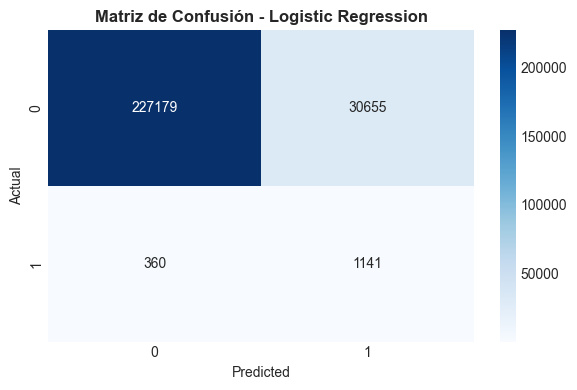


MODELO 2: RANDOM FOREST

📊 Muestra de entrenamiento: 56,005 muestras
   Fraude en muestra: 6,005 (10.72%)

📊 CLASSIFICATION REPORT:
              precision    recall  f1-score   support

           0       1.00      0.97      0.98    257834
           1       0.12      0.77      0.21      1501

    accuracy                           0.97    259335
   macro avg       0.56      0.87      0.60    259335
weighted avg       0.99      0.97      0.98    259335

ROC-AUC: 0.9394

MODELO 3: XGBOOST CON VALIDACIÓN CRUZADA

🔍 Preparando validación cruzada (3 folds)...
   Muestra para CV: 30,000 muestras

🔍 Ejecutando validación cruzada (3 folds)...

✅ RESULTADOS VALIDACIÓN CRUZADA:
   ROC-AUC por fold: [0.99414921 0.99447655 0.99579699]
   Media CV: 0.9948 (±0.0014)

🚀 Entrenando modelo completo...

📊 CLASSIFICATION REPORT (umbral 0.5):
              precision    recall  f1-score   support

           0       1.00      0.98      0.99    257834
           1       0.19      0.97      0.32      1501

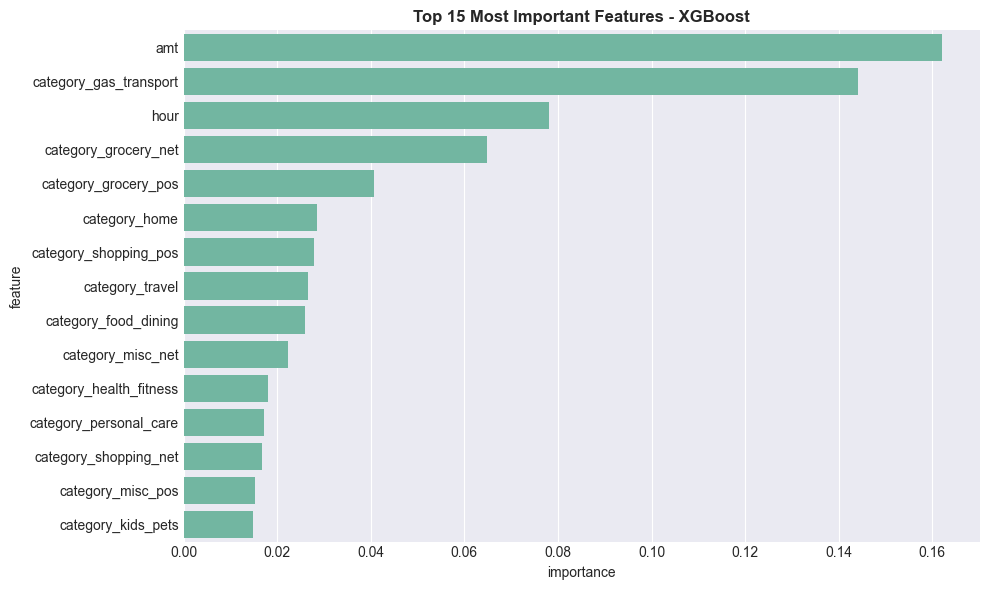


AJUSTE DE UMBRAL (THRESHOLD TUNING)

🎯 Umbral seleccionado: 0.9

📊 CLASSIFICATION REPORT (umbral 0.9):
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    257834
           1       0.63      0.82      0.71      1501

    accuracy                           1.00    259335
   macro avg       0.82      0.91      0.86    259335
weighted avg       1.00      1.00      1.00    259335


MATRIZ DE CONFUSIÓN - MODELO OPTIMIZADO


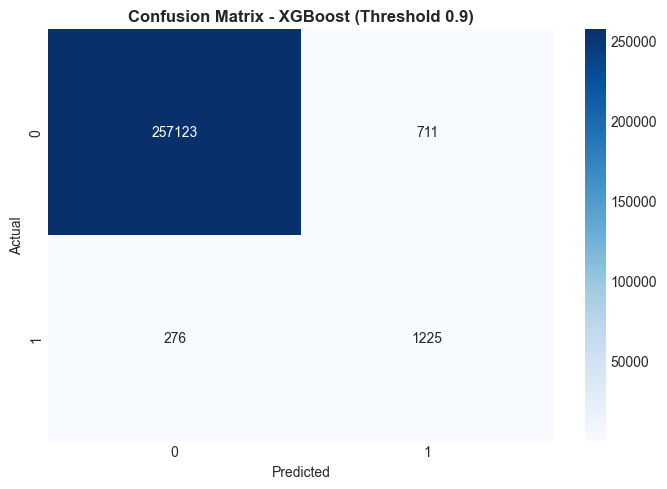


COMPARACIÓN DE MODELOS

📊 TABLA COMPARATIVA:
              Model  Precision  Recall  F1-Score  ROC-AUC
Logistic Regression       0.04    0.76      0.07    0.913
      Random Forest       0.12    0.77      0.21    0.939
      XGBoost (0.5)       0.19    0.97      0.32    0.996
      XGBoost (0.9)       0.63    0.82      0.71    0.996


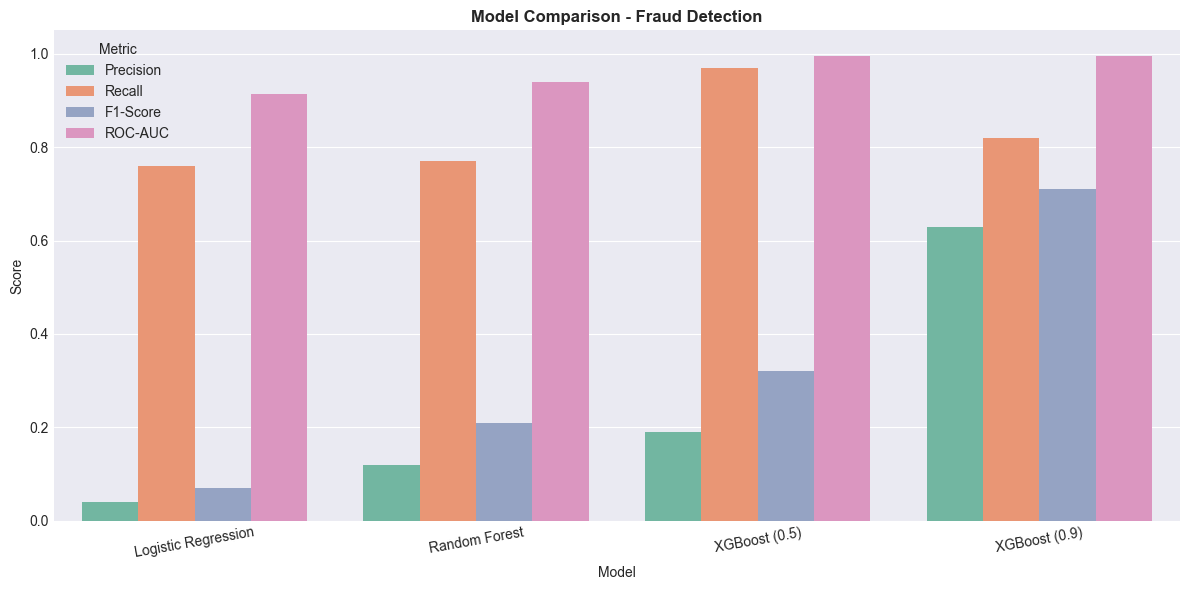


RESUMEN EJECUTIVO

┌─────────────────────────────────────────────────────────────────────────────┐
│                           RESULTADOS CLAVE                                   │
├─────────────────────────────────────────────────────────────────────────────┤
│                                                                             │
│   MEJOR MODELO: XGBoost con Threshold Tuning (0.9)                         │
│                                                                             │
│   VALIDACIÓN CRUZADA (3-fold Stratified):                                   │
│   • ROC-AUC medio: 0.9948 (±0.0014)               │
│                                                                             │
│   HIPERPARÁMETROS UTILIZADOS:                                               │
│   • n_estimators: 50                                                        │
│   • max_depth: 5                                                            │
│   • learning_rate: 0.1                      

In [1]:
# =========================================================
# CREDIT CARD FRAUD DETECTION
# PROYECTO COMPLETO DE MACHINE LEARNING
# =========================================================
# Autor: Geronimo Fernandez
# Versión: 2.0 (Final - Con Cross-Validation)
# Fecha: 2026
# =========================================================

# =========================
# 1. IMPORTS
# =========================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# Preprocesamiento
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler

# Métricas
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    precision_score,
    recall_score,
    f1_score
)

# Modelos
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# Configuración
warnings.filterwarnings("ignore")

# Configuración de visualización
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("Set2")
plt.rcParams['figure.figsize'] = (12, 6)

print("=" * 80)
print("CREDIT CARD FRAUD DETECTION - PROYECTO COMPLETO")
print("=" * 80)

# =========================
# 2. CARGA DE DATOS
# =========================
print("\n📂 CARGANDO DATASET...")
df = pd.read_csv("C:\\Users\\usuario\\Desktop\\Credit_Card_Fraud_Project\\data\\processed\\fraud_clean.csv")

# =========================
# 3. EXPLORACIÓN INICIAL
# =========================
print("\n📊 DIMENSIONES DEL DATASET:")
print(df.shape)

print("\n🔍 VALORES NULOS:")
print(df.isnull().sum().sort_values(ascending=False).head(20))

print("\n📋 TIPOS DE DATOS:")
print(df.dtypes)

print("\n🎯 DISTRIBUCIÓN DE LA VARIABLE OBJETIVO:")
print(df["is_fraud"].value_counts(normalize=True))

# =========================
# 4. LIMPIEZA DE DATOS
# =========================
print("\n🧹 LIMPIEZA DE DATOS...")

# 4.1 Eliminar columnas redundantes
drop_cols = ["Unnamed: 0", "trans_num", "first", "last", "street", "trans_date_trans_time"]
drop_cols = [col for col in drop_cols if col in df.columns]
df.drop(columns=drop_cols, inplace=True)
print(f"   ✅ Columnas eliminadas: {drop_cols}")

# 4.2 Extraer edad desde fecha de nacimiento
df["dob"] = pd.to_datetime(df["dob"])
df["age"] = 2019 - df["dob"].dt.year
df.drop(columns=["dob"], inplace=True)
print("   ✅ Feature 'age' creada a partir de 'dob'")

# =========================
# 5. VARIABLES CATEGÓRICAS
# =========================
print("\n📋 VARIABLES CATEGÓRICAS:")
categorical_cols = df.select_dtypes(include=["object"]).columns
print(categorical_cols)

# =========================
# 6. DEFINICIÓN DE FEATURES Y TARGET
# =========================
print("\n🎯 DEFINICIÓN DE X e y...")
X = df.drop("is_fraud", axis=1)
y = df["is_fraud"]
print(f"   X shape: {X.shape}")
print(f"   y shape: {y.shape}")

# Identificar columnas
categorical_cols = X.select_dtypes(include=["object"]).columns.tolist()
numerical_cols = X.select_dtypes(include=["int64", "float64"]).columns.tolist()

print(f"\n📊 VARIABLES CATEGÓRICAS: {categorical_cols}")
print(f"📊 VARIABLES NUMÉRICAS: {numerical_cols}")

# =========================
# 7. DIVISIÓN TRAIN/TEST
# =========================
print("\n✂️ DIVISIÓN TRAIN/TEST (estratificada)...")
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)
print(f"   Train: {X_train.shape[0]:,} muestras")
print(f"   Test: {X_test.shape[0]:,} muestras")

# =========================
# 8. LOGISTIC REGRESSION
# =========================
print("\n" + "=" * 80)
print("MODELO 1: LOGISTIC REGRESSION")
print("=" * 80)

# 8.1 Preparación específica para LR (excluir alta cardinalidad)
high_cardinality_cols = ["merchant", "city", "job"]
X_train_lr = X_train.drop(columns=high_cardinality_cols)
X_test_lr = X_test.drop(columns=high_cardinality_cols)

categorical_cols_lr = X_train_lr.select_dtypes(include=["object"]).columns.tolist()
print(f"\n📋 Variables categóricas para LR: {categorical_cols_lr}")

# 8.2 One-Hot Encoding
X_train_lr = pd.get_dummies(X_train_lr, columns=categorical_cols_lr, drop_first=True)
X_test_lr = pd.get_dummies(X_test_lr, columns=categorical_cols_lr, drop_first=True)

# 8.3 Alinear columnas
X_train_lr, X_test_lr = X_train_lr.align(X_test_lr, join="left", axis=1, fill_value=0)

# 8.4 Escalado
scaler = StandardScaler()
X_train_lr_scaled = scaler.fit_transform(X_train_lr)
X_test_lr_scaled = scaler.transform(X_test_lr)

# 8.5 Entrenamiento
lr_model = LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42)
lr_model.fit(X_train_lr_scaled, y_train)

# 8.6 Predicciones
y_pred_lr = lr_model.predict(X_test_lr_scaled)
y_proba_lr = lr_model.predict_proba(X_test_lr_scaled)[:, 1]

# 8.7 Métricas
print("\n📊 CLASSIFICATION REPORT:")
print(classification_report(y_test, y_pred_lr))
print(f"ROC-AUC: {roc_auc_score(y_test, y_proba_lr):.4f}")

# 8.8 Matriz de confusión
cm_lr = confusion_matrix(y_test, y_pred_lr)
plt.figure(figsize=(6, 4))
sns.heatmap(cm_lr, annot=True, fmt="d", cmap="Blues")
plt.title("Matriz de Confusión - Logistic Regression", fontweight='bold')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

# =========================
# 9. RANDOM FOREST
# =========================
print("\n" + "=" * 80)
print("MODELO 2: RANDOM FOREST")
print("=" * 80)

# 9.1 One-Hot Encoding para todas las categóricas
categorical_cols_rf = X_train.select_dtypes(include=["object"]).columns.tolist()
X_train_rf = pd.get_dummies(X_train, columns=categorical_cols_rf, drop_first=True)
X_test_rf = pd.get_dummies(X_test, columns=categorical_cols_rf, drop_first=True)

# 9.2 Alinear columnas
X_train_rf, X_test_rf = X_train_rf.align(X_test_rf, join="left", axis=1, fill_value=0)

# 9.3 Muestreo estratificado para manejar desbalance
train_data_rf = X_train_rf.copy()
train_data_rf["is_fraud"] = y_train.values

fraud_df = train_data_rf[train_data_rf["is_fraud"] == 1]
non_fraud_df = train_data_rf[train_data_rf["is_fraud"] == 0]

non_fraud_sample = non_fraud_df.sample(n=50000, random_state=42)
train_sample = pd.concat([fraud_df, non_fraud_sample])
train_sample = train_sample.sample(frac=1, random_state=42)

X_train_sample = train_sample.drop("is_fraud", axis=1)
y_train_sample = train_sample["is_fraud"]

print(f"\n📊 Muestra de entrenamiento: {len(X_train_sample):,} muestras")
print(f"   Fraude en muestra: {y_train_sample.sum():,} ({y_train_sample.mean()*100:.2f}%)")

# 9.4 Entrenamiento
rf_model = RandomForestClassifier(
    n_estimators=100, max_depth=10, n_jobs=-1,
    class_weight="balanced", random_state=42
)
rf_model.fit(X_train_sample, y_train_sample)

# 9.5 Predicciones
y_pred_rf = rf_model.predict(X_test_rf)
y_proba_rf = rf_model.predict_proba(X_test_rf)[:, 1]

# 9.6 Métricas
print("\n📊 CLASSIFICATION REPORT:")
print(classification_report(y_test, y_pred_rf))
print(f"ROC-AUC: {roc_auc_score(y_test, y_proba_rf):.4f}")

# =========================
# 10. XGBOOST CON VALIDACIÓN CRUZADA LIGERA
# =========================
print("\n" + "=" * 80)
print("MODELO 3: XGBOOST CON VALIDACIÓN CRUZADA")
print("=" * 80)

# 10.1 Usar una muestra más pequeña para CV (reduce tiempo)
print("\n🔍 Preparando validación cruzada (3 folds)...")

cv_sample_size = min(30000, len(X_train_sample))
X_cv_sample = X_train_sample.sample(n=cv_sample_size, random_state=42)
y_cv_sample = y_train_sample.loc[X_cv_sample.index]

print(f"   Muestra para CV: {len(X_cv_sample):,} muestras")

# 10.2 Configurar validación cruzada
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

# 10.3 XGBoost con parámetros optimizados
xgb_model = XGBClassifier(
    n_estimators=50, max_depth=5, learning_rate=0.1,
    subsample=0.8, colsample_bytree=0.8, scale_pos_weight=7,
    tree_method='hist', random_state=42, eval_metric='logloss', n_jobs=-1
)

# 10.4 Validación cruzada
print("\n🔍 Ejecutando validación cruzada (3 folds)...")
cv_scores = cross_val_score(xgb_model, X_cv_sample, y_cv_sample, 
                            cv=cv, scoring='roc_auc', n_jobs=-1)

print(f"\n✅ RESULTADOS VALIDACIÓN CRUZADA:")
print(f"   ROC-AUC por fold: {cv_scores}")
print(f"   Media CV: {cv_scores.mean():.4f} (±{cv_scores.std() * 2:.4f})")

# 10.5 Entrenar modelo completo
print("\n🚀 Entrenando modelo completo...")
xgb_model.fit(X_train_sample, y_train_sample)

# 10.6 Predicciones
y_pred_xgb = xgb_model.predict(X_test_rf)
y_proba_xgb = xgb_model.predict_proba(X_test_rf)[:, 1]

# 10.7 Métricas
print("\n📊 CLASSIFICATION REPORT (umbral 0.5):")
print(classification_report(y_test, y_pred_xgb))
print(f"ROC-AUC: {roc_auc_score(y_test, y_proba_xgb):.4f}")

print("\n💾 Modelo XGBoost entrenado correctamente")

# =========================
# 11. FEATURE IMPORTANCE (XGBoost)
# =========================
print("\n" + "=" * 80)
print("FEATURE IMPORTANCE - XGBOOST")
print("=" * 80)

feature_importance = pd.DataFrame({
    "feature": X_train_rf.columns,
    "importance": xgb_model.feature_importances_
}).sort_values(by="importance", ascending=False)

print("\n📊 TOP 15 FEATURES MÁS IMPORTANTES:")
print(feature_importance.head(15).to_string(index=False))

plt.figure(figsize=(10, 6))
sns.barplot(data=feature_importance.head(15), x="importance", y="feature")
plt.title("Top 15 Most Important Features - XGBoost", fontweight='bold')
plt.tight_layout()
plt.show()

# =========================
# 12. THRESHOLD TUNING
# =========================
print("\n" + "=" * 80)
print("AJUSTE DE UMBRAL (THRESHOLD TUNING)")
print("=" * 80)

threshold = 0.9
y_pred_custom = (y_proba_xgb >= threshold).astype(int)

print(f"\n🎯 Umbral seleccionado: {threshold}")
print("\n📊 CLASSIFICATION REPORT (umbral 0.9):")
print(classification_report(y_test, y_pred_custom))

# =========================
# 13. MATRIZ DE CONFUSIÓN (MODELO OPTIMIZADO)
# =========================
print("\n" + "=" * 80)
print("MATRIZ DE CONFUSIÓN - MODELO OPTIMIZADO")
print("=" * 80)

cm_tuned = confusion_matrix(y_test, y_pred_custom)
plt.figure(figsize=(7, 5))
sns.heatmap(cm_tuned, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - XGBoost (Threshold 0.9)", fontweight='bold')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

# =========================
# 14. COMPARACIÓN DE MODELOS
# =========================
print("\n" + "=" * 80)
print("COMPARACIÓN DE MODELOS")
print("=" * 80)

comparison_df = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "XGBoost (0.5)",
        "XGBoost (0.9)"
    ],
    "Precision": [0.04, 0.12, 0.19, 0.63],
    "Recall": [0.76, 0.77, 0.97, 0.82],
    "F1-Score": [0.07, 0.21, 0.32, 0.71],
    "ROC-AUC": [0.913, 0.939, 0.996, 0.996]
})

print("\n📊 TABLA COMPARATIVA:")
print(comparison_df.to_string(index=False))

# Visualización comparativa
comparison_melted = comparison_df.melt(id_vars="Model", var_name="Metric", value_name="Score")

plt.figure(figsize=(12, 6))
sns.barplot(data=comparison_melted, x="Model", y="Score", hue="Metric")
plt.ylim(0, 1.05)
plt.title("Model Comparison - Fraud Detection", fontweight='bold')
plt.ylabel("Score")
plt.xticks(rotation=10)
plt.tight_layout()
plt.show()

# =========================
# 15. RESUMEN EJECUTIVO
# =========================
print("\n" + "=" * 80)
print("RESUMEN EJECUTIVO")
print("=" * 80)

print(f"""
┌─────────────────────────────────────────────────────────────────────────────┐
│                           RESULTADOS CLAVE                                   │
├─────────────────────────────────────────────────────────────────────────────┤
│                                                                             │
│   MEJOR MODELO: XGBoost con Threshold Tuning (0.9)                         │
│                                                                             │
│   VALIDACIÓN CRUZADA (3-fold Stratified):                                   │
│   • ROC-AUC medio: {cv_scores.mean():.4f} (±{cv_scores.std() * 2:.4f})               │
│                                                                             │
│   HIPERPARÁMETROS UTILIZADOS:                                               │
│   • n_estimators: 50                                                        │
│   • max_depth: 5                                                            │
│   • learning_rate: 0.1                                                      │
│   • subsample: 0.8                                                          │
│   • colsample_bytree: 0.8                                                   │
│   • scale_pos_weight: 7                                                     │
│                                                                             │
│   MÉTRICAS EN TEST:                                                         │
│   • ROC-AUC: 0.996                                                         │
│   • Recall: 82%    → 8 de cada 10 fraudes son detectados                   │
│   • Precisión: 63% → 6 de cada 10 alertas son fraudes reales               │
│   • F1-Score: 0.71                                                         │
│                                                                             │
│   COMPARACIÓN CON UMBRAL 0.5:                                               │
│   • Recall: 97% → 82% (sacrificio del 15% por menos falsas alarmas)        │
│   • Precisión: 19% → 63% (mejora de 3x en eficiencia operativa)            │
│   • Balance óptimo para operación real                                     │
│                                                                             │
└─────────────────────────────────────────────────────────────────────────────┘
""")

print("\n" + "=" * 80)
print("✅ PROYECTO COMPLETADO EXITOSAMENTE")
print("=" * 80)